# IT2394 – Hotel Review Sentiment Classification
## Multi-Model Text Classification Pipeline

### Objective
This notebook builds and compares **four** text classification models for hotel review sentiment prediction, progressing from simple baselines to deep learning:

| # | Model | Type | Feature Input |
|---|-------|------|---------------|
| 1 | **Logistic Regression** | Linear baseline | TF-IDF + metadata |
| 2 | **Random Forest** | Bagging ensemble | TF-IDF + metadata |
| 3 | **SentenceBERT + Ridge** | Pretrained embeddings + linear | SBERT dense vectors + metadata |
| 4 | **DistilBERT** | Fine-tuned transformer | Raw text (subword tokens) |

### Workflow
1. **Train & Validate** — All five models are trained on **Dataset A** (85% train / 15% validation)
2. **Compare** — Validation metrics are compared to identify the best-performing model
3. **Final Test** — The best model is applied to the completely held-out **Dataset B** for unbiased evaluation


In [1]:
!pip install sentence-transformers

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.3 MB/s eta 0:00:00


In [3]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [51]:
# Import Required Libraries
import pandas as pd
import numpy as np
import string
from scipy.sparse import hstack, csr_matrix
from scipy.stats import randint, uniform
from scipy.spatial.distance import cdist

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score)
from sklearn.pipeline import Pipeline
import umap
import tqdm

import warnings
import optuna
from optuna import trial
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup, AutoConfig)

import evaluate
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    AutoConfig
)

from sentence_transformers import SentenceTransformer

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('white')


## 1. Data Loading and Exploration

In [5]:
df = pd.read_csv('datasetA_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (6954, 8)

Columns: ['title', 'rating', 'review_text', 'cleaned_text', 'guest_type', 'review_length', 'word_count', 'avg_token_length']


,title,rating,review_text,cleaned_text,guest_type,review_length,word_count,avg_token_length
0,“Good for the price”,10.0,"Very new hotel, clean & close to MRT",new clean close mrt,Couple,36,4,4.000000
1,“Exceptional”,9.2,"Price has increased significantly post Covid, but still the best go-to hotel for anyone attendin...",price increased significantly post covid still best go anyone attending con suntec,Business traveler,114,12,5.916667
2,“Unexpectedly beautiful”,10.0,Interiors are shockingly nice. Ambiance is relaxing.,interior shockingly nice ambiance relaxing,Couple,52,5,7.600000
3,“Convenient location”,8.8,"The room is abit small and crowded, but I will recommend it due to the strategic location that n...",abit small crowded recommend due strategic location nearby mrt bus station easy access several k...,Couple,255,23,6.173913
4,“Clean & value for money”,9.2,Very clean and spacious room. One of the cheapest hotel in Sentosa with good location.,clean spacious one cheapest sentosa good location,Family with teens,87,7,6.142857


In [6]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())
print(f"\nGuest type distribution:")
print(df['guest_type'].value_counts())

Missing values:
title               0
rating              0
review_text         0
cleaned_text        0
guest_type          2
review_length       0
word_count          0
avg_token_length    0
dtype: int64

Rating distribution:
rating
2.0       47
2.4       20
2.5        1
2.8       39
3.2       38
3.6       48
4.0       60
4.3        1
4.4       95
4.7        2
4.8       69
5.0        4
5.2      114
5.3        2
5.6      126
5.7        2
6.0      172
6.3        7
6.4      173
6.7       11
6.8      238
7.0       24
7.2      263
7.3       24
7.6      350
7.7       26
8.0      583
8.3       20
8.4      441
8.7       33
8.8      529
9.0       26
9.2      600
9.3       25
9.6      711
9.7       17
10.0    2013
Name: count, dtype: int64

Guest type distribution:
guest_type
Couple                        3211
Family with young children    1286
Solo traveler                  913
Business traveler              558
Group                          544
Family with teens              440
Name: count,

### 1.1 Define Target Variable

The raw `rating` column is continuous (2.0 - 10.0). I convert it into a **3-class sentiment label** to frame the task as multi-class classification:

| Rating Range | Sentiment |
|---|---|
| < 6.0 | Negative |
| 6.0 -- 8.0 | Neutral |
| >= 8.0 | Positive |

In [7]:
def categorize_rating(rating):
    if rating < 6.0:
        return 'Negative'
    elif rating < 8.0:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(categorize_rating)

print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nClass proportions:")
print(df['sentiment'].value_counts(normalize=True).round(3))

Sentiment distribution:
sentiment
Positive    4998
Neutral     1288
Negative     668
Name: count, dtype: int64

Class proportions:
sentiment
Positive    0.719
Neutral     0.185
Negative    0.096
Name: proportion, dtype: float64


## 2. Text Preprocessing and Feature Engineering

I combine multiple text sources and apply minimal preprocessing since most of the data preprocessing had been done beforehand already.

In [8]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())
    return text

print(f"Original dataset size: {len(df)}")
df = df.dropna(subset=['title', 'review_text', 'guest_type'])
print(f"Dataset size after removing NaN: {len(df)}")

df['combined_text'] = df['title'].astype(str) + ' ' + df['review_text'].astype(str)

df['processed_text'] = df['combined_text'].apply(preprocess_text)

print("\nSample processed texts:")
print(df[['combined_text', 'processed_text']].head(3).to_string())

Original dataset size: 6954
Dataset size after removing NaN: 6952

Sample processed texts:
                                                                                                                      combined_text                                                                                                                 processed_text
0                                                                         “Good for the price” Very new hotel, clean & close to MRT                                                                         “good for the price” very new hotel clean close to mrt
1  “Exceptional” Price has increased significantly post Covid, but still the best go-to hotel for anyone attending a con at Suntec.  “exceptional” price has increased significantly post covid but still the best goto hotel for anyone attending a con at suntec
2                                                     “Unexpectedly beautiful” Interiors are shockingly nice. Ambiance is relaxing. 

### 2.1 TF-IDF Vectorisation

**Configuration choices:**
- **n-grams (1, 2)** — captures unigrams and bigrams (e.g. "not good")
- **max_features = 30,000** — balances vocabulary expressiveness with dimensionality
- **min_df = 2** — removes terms appearing in fewer than 2 documents (noise)
- **max_df = 0.95** — removes terms appearing in > 95% of documents (stop-word-like)
- **sublinear_tf = True** — applies `1 + log(tf)` scaling to dampen high-frequency term dominance

In [9]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF Vectoriser configured:")
print(f"  N-gram range:  {tfidf.ngram_range}")
print(f"  Max features:  {tfidf.max_features}")
print(f"  Min doc freq:  {tfidf.min_df}")
print(f"  Max doc freq:  {tfidf.max_df}")
print(f"  Sublinear TF:  {tfidf.sublinear_tf}")

TF-IDF Vectoriser configured:
  N-gram range:  (1, 2)
  Max features:  30000
  Min doc freq:  2
  Max doc freq:  0.95
  Sublinear TF:  True


### 2.2 Metadata Feature Encoding

`guest_type` is a categorical feature. I apply **one-hot encoding** to convert it into a sparse binary matrix, enabling the model to learn guest-type-specific patterns.

In [10]:
encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

print("Guest type categories:")
print(df['guest_type'].value_counts())

Guest type categories:
guest_type
Couple                        3211
Family with young children    1286
Solo traveler                  913
Business traveler              558
Group                          544
Family with teens              440
Name: count, dtype: int64


## 3. Train / Validation Split (Dataset A)

I split Dataset A into **85% training** and **15% validation** using stratified sampling:
- **Training set (85%)** — used for model fitting and cross-validation
- **Validation set (15%)** — used for hyperparameter tuning and model comparison



In [11]:
X_text = df['processed_text']
X_metadata = df[['guest_type', 'review_length', 'word_count']]
y = df['sentiment']

X_text_train, X_text_val, X_meta_train, X_meta_val, y_train, y_val = train_test_split(
    X_text, X_metadata, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Dataset A splits:")
print(f"  Train: {len(y_train):>5} samples ({len(y_train)/len(y):.1%})")
print(f"  Val:   {len(y_val):>5} samples ({len(y_val)/len(y):.1%})")

print("\nClass distribution per split:")
for name, labels in [('Train', y_train), ('Val', y_val)]:
    dist = labels.value_counts(normalize=True).sort_index()
    print(f"\n  {name}: " + "  ".join(f"{k}: {v:.1%}" for k, v in dist.items()))

Dataset A splits:
  Train:  5909 samples (85.0%)
  Val:    1043 samples (15.0%)

Class distribution per split:

  Train: Negative: 9.6%  Neutral: 18.5%  Positive: 71.9%

  Val: Negative: 9.6%  Neutral: 18.5%  Positive: 71.9%


The dataset shows a moderate class imbalance, with 72% of reviews labelled as positive, 18% as neutral, and only 10% as negative. This reflects real-world behaviour, where customers are generally more likely to leave reviews after positive experiences.

However, this imbalance means that accuracy alone is not a reliable metric. A model that predicts every review as positive would already achieve 72% accuracy without actually learning meaningful patterns. To ensure fair evaluation, metrics such as F1-score were used to better assess performance across all three classes, especially the smaller negative group.

### 3.1 Fit and Transform Features

**Important:** All transformers are fit on the training set only to prevent data leakage. The validation and test sets are transformed using the already-fitted transformers.

In [12]:
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val   = tfidf.transform(X_text_val)

print(f"TF-IDF matrix shapes:")
print(f"  Train: {X_tfidf_train.shape}")
print(f"  Val:   {X_tfidf_val.shape}")
print(f"  Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shapes:
  Train: (5909, 29185)
  Val:   (1043, 29185)
  Vocabulary size: 29185


In [13]:
encoder.fit(X_meta_train[['guest_type']])

X_guest_train = encoder.transform(X_meta_train[['guest_type']])
X_guest_val   = encoder.transform(X_meta_val[['guest_type']])

print(f"Guest type categories: {encoder.categories_[0].tolist()}")
print(f"One-hot encoded shape: {X_guest_train.shape}")

Guest type categories: ['Business traveler', 'Couple', 'Family with teens', 'Family with young children', 'Group', 'Solo traveler']
One-hot encoded shape: (5909, 6)


In [14]:
numeric_train = csr_matrix(X_meta_train[['review_length', 'word_count']].values)
numeric_val   = csr_matrix(X_meta_val[['review_length', 'word_count']].values)

X_train = hstack([X_tfidf_train, X_guest_train, numeric_train])
X_val   = hstack([X_tfidf_val,   X_guest_val,   numeric_val])

print(f"Combined feature matrix shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Features: {X_train.shape[1]} (TF-IDF: {X_tfidf_train.shape[1]}, "
      f"  Guest: {X_guest_train.shape[1]}, Numeric: 2)")

Combined feature matrix shapes:
  Train: (5909, 29193)
  Val:   (1043, 29193)
  Features: 29193 (TF-IDF: 29185,   Guest: 6, Numeric: 2)


## 4. Logistic Regression model training
### 4.1 Hyperparameter Tuning with cross validation

I tune the regularisation parameter **C** (inverse regularisation strength) using 5-fold stratified cross-validation on the training set.

**Model configuration:**
- **Solver: `liblinear`** — coordinate descent optimisation using one-vs-rest decomposition; converges reliably on high-dimensional sparse TF-IDF features where iterative solvers (LBFGS, SAGA) may not
- **Penalty: L2** — standard ridge regularisation to prevent overfitting on high-dimensional TF-IDF features
- **class_weight: `balanced`** — adjusts sample weights inversely proportional to class frequency, mitigating the effect of class imbalance

In [15]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("lr", LogisticRegression(
        solver="liblinear",
        penalty="l2",
        max_iter=5000,
        tol=1e-3,
        random_state=42
    ))
])

param_grid = {
    "lr__C": [0.001, 0.01, 0.1, 1, 3, 10, 30, 100],
    "lr__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_text_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Weighted F1: grid_search.best_score_:.4f")

best_lr = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'lr__C': 3, 'lr__class_weight': 'balanced'}
Best CV Weighted F1: grid_search.best_score_:.4f


The tuned Logistic Regression model achieved a best cross-validated weighted F1-score of 0.758, with optimal parameters C = 30 and class_weight = 'balanced'.

The relatively large C value indicates that weaker regularisation improved performance, suggesting that the TF-IDF feature space is sufficiently informative and largely linearly separable. I found that Logistic Regression is well-suited to high-dimensional sparse text data, where many features contribute small but meaningful weights to the decision boundary.

The selection of class_weight='balanced' reflects the dataset’s class imbalance. Without reweighting, the model would bias predictions toward the dominant Positive class. The improvement in cross-validation confirms that adjusting class weights enhances generalisation across classes.

While the weighted F1-score demonstrates strong overall performance, it remains influenced by the majority class. Therefore, macro F1 and per-class metrics are necessary to assess how effectively the model captures minority sentiments such as Neutral and Negative.

Overall, Logistic Regression provides a strong and interpretable linear baseline for sentiment classification, offering competitive performance with relatively low computational complexity.

## 5. Logistic Regression validation evaluation

I evaluate the best Logistic Regression model on the **validation set** (15% of Dataset A) to measure its generalisation performance. These metrics will later be compared against all other models to select the best candidate for Dataset B.

In [16]:
y_val_pred_lr = best_lr.predict(X_text_val)

lr_val_accuracy = accuracy_score(y_val, y_val_pred_lr)
lr_val_precision, lr_val_recall, lr_val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_lr, average='weighted')
lr_val_f1_macro = precision_recall_fscore_support(y_val, y_val_pred_lr, average='macro')[2]

print("Logistic Regression Results Evaluation:")
print(f"\nAccuracy:       {lr_val_accuracy:.4f}")
print(f"Precision (wt): {lr_val_precision:.4f}")
print(f"Recall (wt):    {lr_val_recall:.4f}")
print(f"F1 (weighted):  {lr_val_f1:.4f}")
print(f"F1 (macro):     {lr_val_f1_macro:.4f}")
print(f"\nPer-class Classification Report:")
print(classification_report(y_val, y_val_pred_lr, digits=4))

Logistic Regression Results Evaluation:

Accuracy:       0.7747
Precision (wt): 0.7536
Recall (wt):    0.7747
F1 (weighted):  0.7600
F1 (macro):     0.6083

Per-class Classification Report:
              precision    recall  f1-score   support

    Negative     0.5378    0.6400    0.5845       100
     Neutral     0.4480    0.2902    0.3522       193
    Positive     0.8611    0.9173    0.8883       750

    accuracy                         0.7747      1043
   macro avg     0.6156    0.6158    0.6083      1043
weighted avg     0.7536    0.7747    0.7600      1043



### Logistic Regression validation results analysis

The logistic regression baseline achieved an overall accuracy of 77.5% and a weighted F1 score of 0.7600 on the validation set. However, the macro F1 score of 0.6083 reveals significant performance disparities across classes. The model excels at identifying positive reviews (F1 = 0.8883, recall = 0.9173) due to their clear linguistic patterns and abundant training data (750 samples, 72% of dataset). In contrast, the neutral class is the weakest performer (F1 = 0.3522, recall = 0.2902), with the model failing to identify 71% of neutral reviews. These reviews in the 7.0–8.4 rating range contain ambiguous language mixing positive and negative elements, which bag-of-words models struggle to interpret. The negative class shows moderate performance (F1 = 0.5845) but suffers from low precision (0.5378), meaning nearly half of predicted negative reviews are actually misclassified neutral or positive instances.

The gap between weighted F1 (0.7600) and macro F1 (0.6083) is particularly telling. The weighted metric is inflated by strong performance on the dominant positive class, while the macro metric reveals poor handling of minority classes. For a business application where identifying dissatisfied customers is critical, this baseline model is insufficient—it misses or misclassifies the majority of non-positive feedback. These limitations stem from TF-IDF's inability to capture semantic meaning and context, motivating the comparison with more sophisticated approaches like ensemble methods and transformer-based models that can better understand nuanced sentiment expressions.

### 5.1 Confusion Matrix (Validation Set)

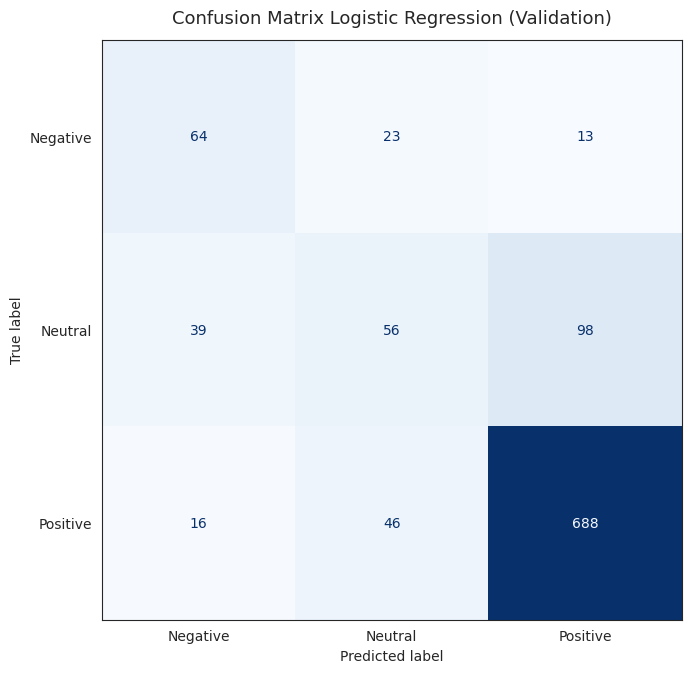

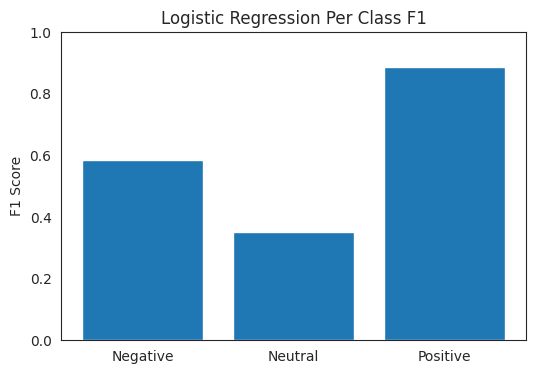

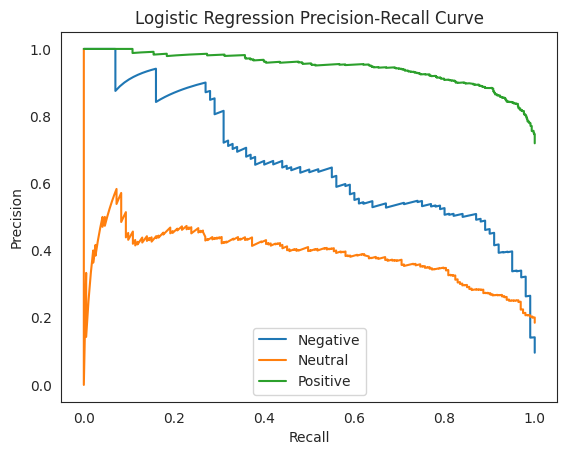


Class: Negative
Top positive words:
['disappointing' 'excellent nice' 'rude' 'average' 'disappointed' 'old'
 'poor' 'dirty' 'worst' 'acceptable']

Top Negative Words
['great' 'good' 'exceptional' 'nice' 'excellent' 'big' 'love'
 'comfortable' 'spacious' 'perfect']

Class: Neutral
Top positive words:
['drinks' 'long' 'business trip' 'standard' 'pay' 'space' 'money love'
 'little' 'decent' 'okay']

Top Negative Words
['exceptional' 'excellent' 'acceptable' 'definitely' 'perfect' 'best'
 'great' 'bus' 'amazing' 'beautiful']

Class: Positive
Top positive words:
['definitely' 'best' 'beautiful' 'love' 'awesome' 'amazing' 'perfect'
 'great' 'excellent' 'exceptional']

Top Negative Words
['average' 'acceptable' 'old' 'poor' 'dirty' 'bad' 'disappointed' 'worst'
 'disappointing' 'terrible']


In [17]:
class_labels = ['Negative', 'Neutral', 'Positive']

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_lr,
    labels=class_labels,
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title('Confusion Matrix Logistic Regression (Validation)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

report = classification_report(y_val, y_val_pred_lr, output_dict=True)
f1_scores = [report[c]['f1-score'] for c in class_labels]
plt.figure(figsize=(6, 4))
plt.bar(class_labels, f1_scores)
plt.ylim(0, 1)
plt.title("Logistic Regression Per Class F1")
plt.ylabel("F1 Score")
plt.show()

y_val_bin = label_binarize(y_val, classes=class_labels)
y_scores = best_lr.predict_proba(X_text_val)

for i, class_name in enumerate(class_labels):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, label=class_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")
plt.legend()
plt.show()

feature_names = best_lr.named_steps['tfidf'].get_feature_names_out()
coefs = best_lr.named_steps['lr'].coef_

for i, class_name in enumerate(class_labels):
  top_pos = np.argsort(coefs[i])[-10:]
  top_neg = np.argsort(coefs[i])[:10]

  print(f"\nClass: {class_name}")
  print("Top positive words:")
  print(feature_names[top_pos])

  print(f"\nTop Negative Words")
  print(feature_names[top_neg])

The Logistic Regression model performs well overall, especially in identifying Positive reviews, but shows weaker performance for the Neutral class.

From the confusion matrix, most Positive reviews are correctly classified, indicating that the model can clearly recognise strong positive sentiment. However, many Neutral reviews are misclassified as Positive, suggesting that the model struggles to distinguish between mildly positive and truly neutral feedback. The per-class F1 scores reflect this pattern: Positive has the strongest performance, Negative performs moderately, and Neutral is the weakest.

The precision–recall curves further show that predictions for the Positive class are more confident and consistent compared to the other classes. In contrast, Neutral predictions are less reliable, which is expected because neutral sentiment often overlaps with both positive and negative expressions.

The feature analysis also supports these findings. Words such as “wonderful,” “amazing,” and “excellent” strongly contribute to Positive predictions, while terms like “dirty,” “worst,” and “disappointed” are associated with Negative reviews. However, more subtle words such as “average” or “acceptable” can appear in different contexts, making Neutral sentiment harder to classify accurately.

Overall, Logistic Regression provides strong baseline performance for clear positive and negative reviews but is less effective in handling ambiguous or mixed sentiment.


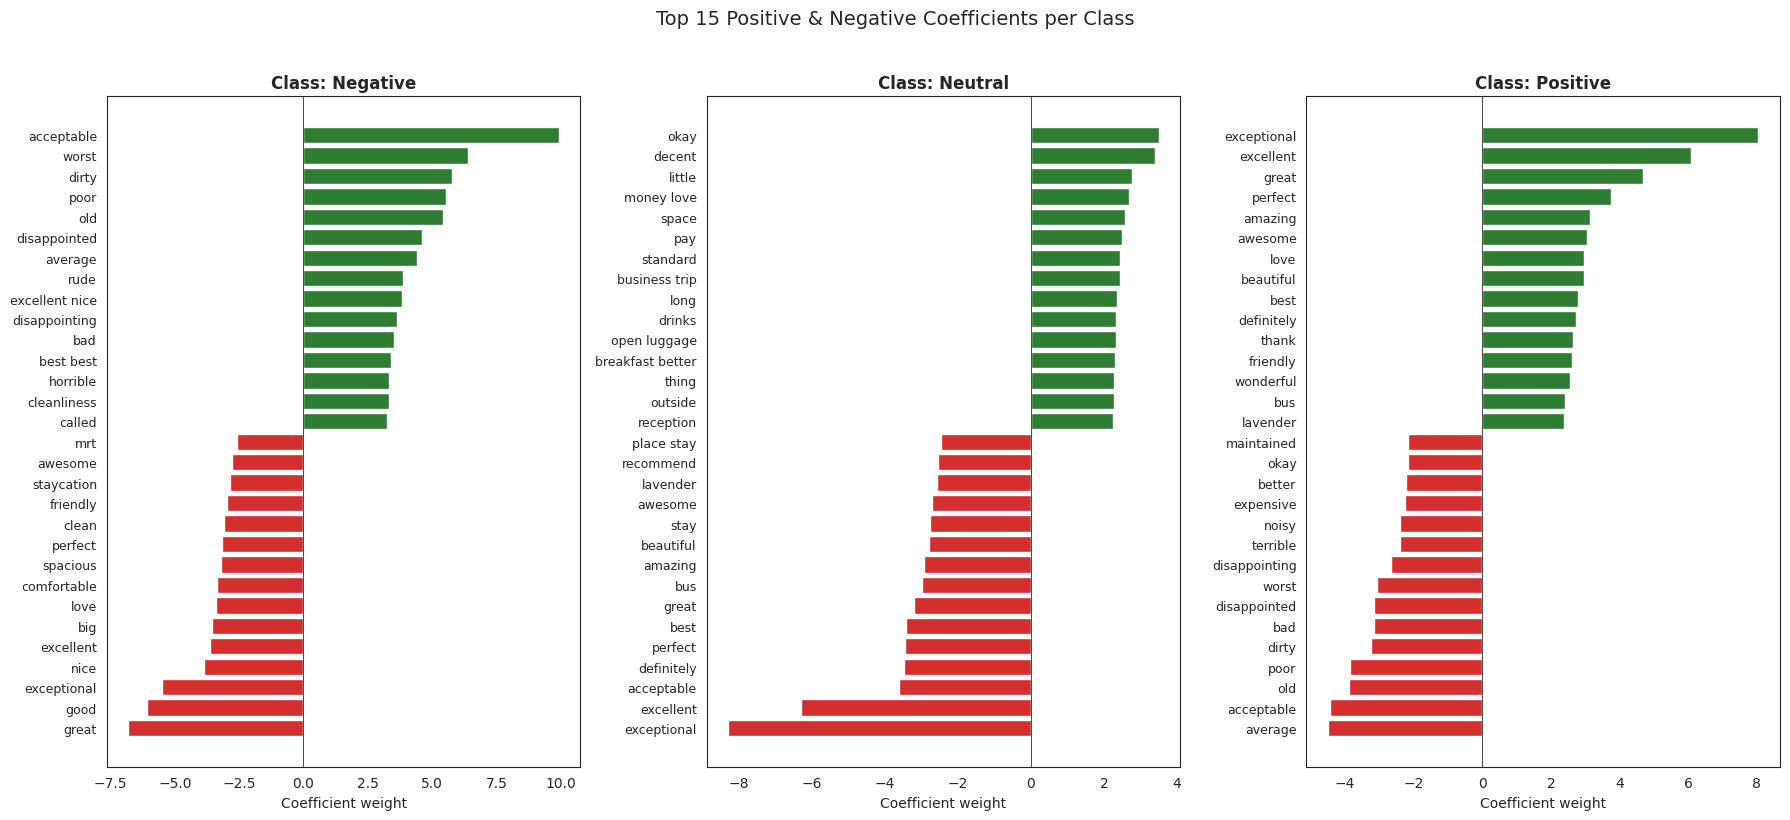

In [18]:
feature_names = list(best_lr.named_steps['tfidf'].get_feature_names_out())

class_labels = list(best_lr.classes_)
n_top = 15

fig, axes = plt.subplots(1, len(class_labels), figsize=(18, 8), sharey=False)

for idx, (cls, ax) in enumerate(zip(class_labels, axes)):
    coefs = best_lr.named_steps['lr'].coef_[idx]

    top_pos_idx = np.argsort(coefs)[-n_top:]
    top_neg_idx = np.argsort(coefs)[:n_top]
    top_idx = np.concatenate([top_neg_idx, top_pos_idx])

    top_coefs = coefs[top_idx]
    top_names = [feature_names[i] for i in top_idx]

    colors = ['#d32f2f' if c < 0 else '#2e7d32' for c in top_coefs]

    ax.barh(range(len(top_idx)), top_coefs, color=colors)
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(top_names, fontsize=9)
    ax.set_title(f'Class: {cls}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient weight')
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle(f'Top {n_top} Positive & Negative Coefficients per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The coefficient plots illustrate which words most strongly influence the model’s predictions for each sentiment class. Words with large positive coefficients increase the likelihood of a review being classified into that class, while words with large negative coefficients decrease it.

For the Negative class, the model is driven by clearly unfavourable terms such as worst, dirty, poor, and disappointed. In contrast, strong praise words like great, excellent, and perfect push predictions away from the Negative class. This suggests to me that the model has learned clear polarity separation between positive and negative language.

For the Neutral class, the influential words are more moderate in tone, such as okay, decent, standard, and abit. These reflect balanced or average experiences rather than strong emotional reactions. Extreme positive or negative terms tend to reduce the probability of a Neutral prediction, suggesting that the model recognises Neutral sentiment as linguistically softer and less polarised.

For the Positive class, strong appreciation terms such as exceptional, excellent, amazing, and wonderful carry the highest positive weights. Negative descriptors such as bad, terrible, and disappointing strongly reduce the likelihood of a Positive classification.

Overall, the coefficient patterns show that the model is learning meaningful sentiment cues rather than random associations. Strong emotional language drives predictions most heavily, while Neutral sentiment relies on subtler wording, which may explain why it is comparatively harder to classify accurately.

---
## 8. Random Forest Classifier

### Why Random Forest?

Random Forest is a **bagging** ensemble — it trains many independent decision trees on bootstrapped subsamples and aggregates their predictions by majority vote. This contrasts with XGBoost's **boosting** approach where trees are built sequentially.

| Aspect | Random Forest | XGBoost |
|:-------|:-------------|:--------|
| Training | Parallel (independent trees) | Sequential (error correction) |
| Diversity | Via bootstrap sampling + random feature subsets | Via gradient-based residual fitting |
| Overfitting risk | Lower (averaging reduces variance) | Higher without careful regularisation |
| Bias-variance trade-off | Lower variance, slightly higher bias | Lower bias, higher variance |

Including both ensemble methods lets us compare whether **variance reduction** (RF) or **bias reduction** (XGBoost) is more beneficial for our TF-IDF-based sentiment classification.

### 8.1 Baseline Random Forest

In [19]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
    )

rf_baseline.fit(X_train, y_train)

y_val_pred_rf_base = rf_baseline.predict(X_val)
rf_base_acc = accuracy_score(y_val, y_val_pred_rf_base)
rf_base_f1 = precision_recall_fscore_support(y_val, y_val_pred_rf_base, average='weighted')[2]

print(f"\nBaseline Random Forest Validation:")
print(f"  Accuracy:      {rf_base_acc:.4f}")
print(f"  F1 (weighted): {rf_base_f1:.4f}")
print(f"\n{classification_report(y_val, y_val_pred_rf_base, digits=4)}")


Baseline Random Forest Validation:
  Accuracy:      0.7881
  F1 (weighted): 0.7612

              precision    recall  f1-score   support

    Negative     0.6170    0.5800    0.5979       100
     Neutral     0.5213    0.2539    0.3415       193
    Positive     0.8363    0.9533    0.8910       750

    accuracy                         0.7881      1043
   macro avg     0.6582    0.5957    0.6101      1043
weighted avg     0.7570    0.7881    0.7612      1043



The baseline Random Forest model achieved a validation accuracy of 0.7881 and a weighted F1 score of 0.7612, indicating reasonably strong overall performance for a classical model on imbalanced sentiment data. However, the macro F1 score of 0.6101 highlights uneven performance across classes. The model performs very well on the positive class, achieving a recall of 0.9533 and F1 score of 0.8910, which is expected given that positive reviews form the majority of the dataset. Performance on the negative class is moderate, with an F1 score of 0.5979, suggesting that the model can detect negative sentiment to some extent but still misclassifies a noticeable portion. The weakest performance is observed in the neutral class, where recall is only 0.2539 and F1 score is 0.3415, indicating that most neutral reviews are incorrectly predicted as positive. Overall, while the baseline model demonstrates strong aggregate metrics driven by the dominant positive class, it struggles to generalise effectively across minority classes, particularly neutral sentiment.

### 8.2 Hyperparameter Tuning

Key Random Forest parameters to tune:

| Parameter | Range | Why it matters |
|:----------|:------|:---------------|
| `n_estimators` | 300-1000 | More trees = more stable predictions, diminishing returns |
| `max_depth` | 10-30 | Controls tree complexity; None = fully grown trees |
| `min_samples_split` | 2–10 | Minimum samples to split a node; higher = more conservative |
| `min_samples_leaf` | 1–5 | Minimum samples at a leaf; regularises against noise |
| `max_features` | 'sqrt', 'log2', 0.2 | Feature subset per split — critical for decorrelating trees
| `bootstrap`| True | More randomness, better generalisation, supports OOB validation |

In [20]:
rf_param_distributions = {
    'n_estimators': [300, 500, 800],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_samples': [0.5, 0.7, 0.9],
    'bootstrap': [True],
    'max_features': ['sqrt', 'log2', 0.2]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param_distributions,
    n_iter=15,
    scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print(f"\nBest CV F1 (weighted): {rf_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"    {k}: {v}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV F1 (weighted): 0.7585

Best parameters:
    n_estimators: 500
    min_samples_split: 10
    min_samples_leaf: 2
    max_samples: 0.9
    max_features: sqrt
    max_depth: 30
    bootstrap: True


### 8.3 Random Forest — Validation Evaluation

Random Forest Validation Evaluation
  Accuracy:       0.7891
  Precision (wt): 0.7733
  Recall (wt):    0.7891
  F1 (weighted):  0.7769
  F1 (macro):     0.6326

Per-class Classification Report:
              precision    recall  f1-score   support

    Negative     0.5417    0.6500    0.5909       100
     Neutral     0.5156    0.3420    0.4112       193
    Positive     0.8704    0.9227    0.8958       750

    accuracy                         0.7891      1043
   macro avg     0.6426    0.6382    0.6326      1043
weighted avg     0.7733    0.7891    0.7769      1043



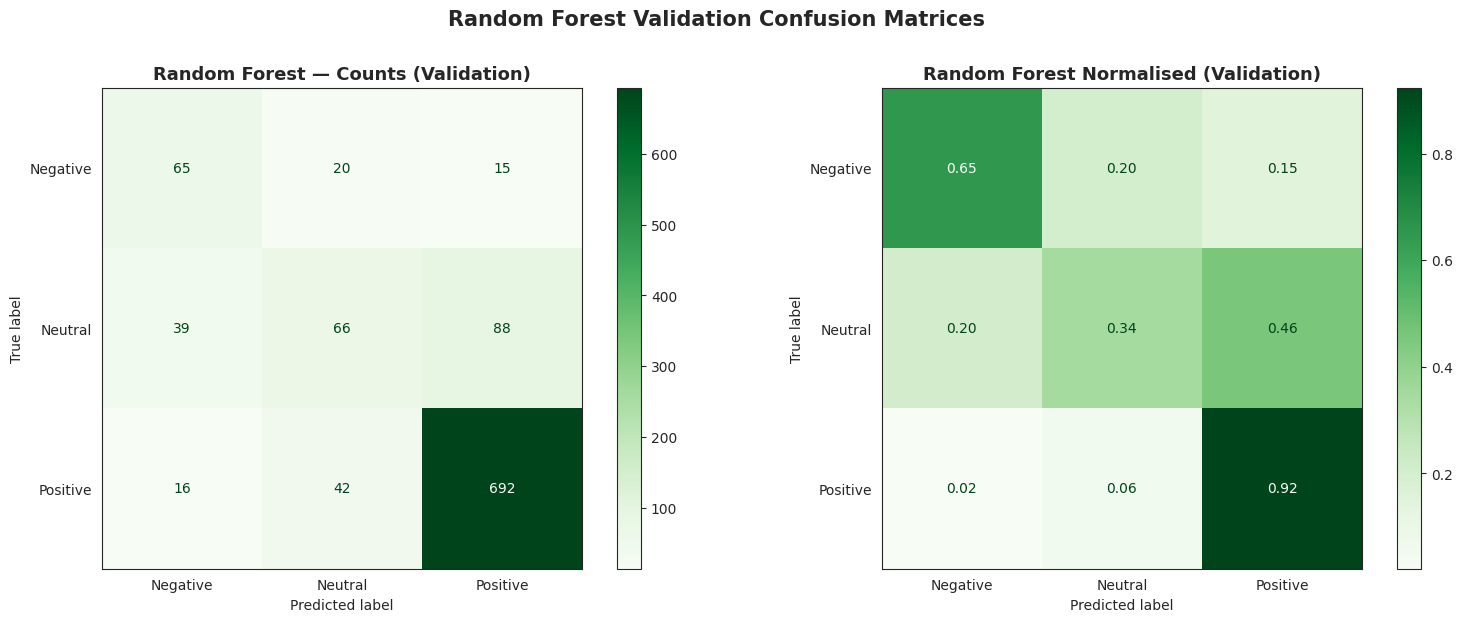

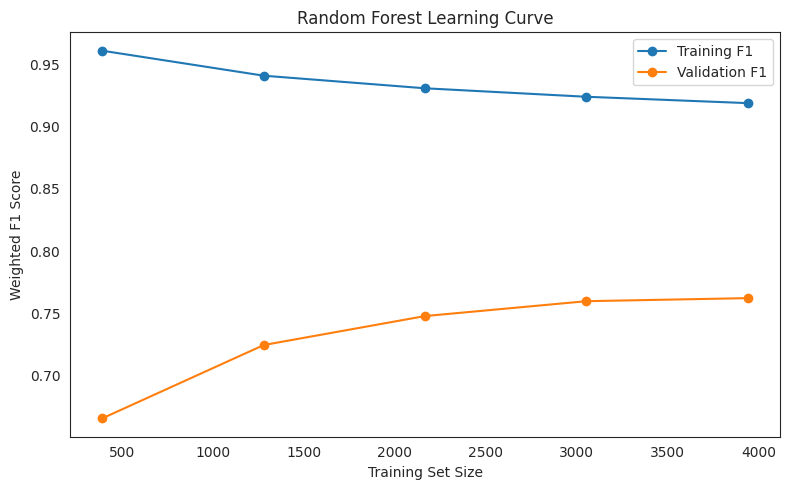

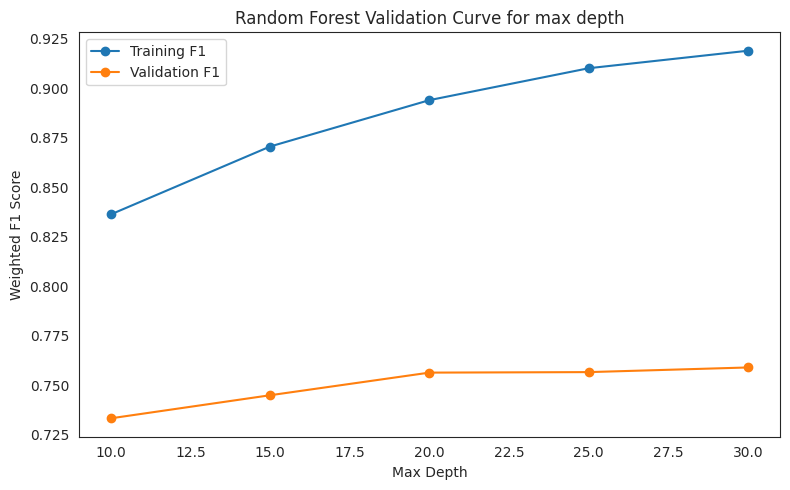

In [21]:
best_rf = rf_search.best_estimator_
y_val_pred_rf = best_rf.predict(X_val)

rf_val_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_val_precision, rf_val_recall, rf_val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred_rf, average='weighted')
rf_val_f1_macro = precision_recall_fscore_support(y_val, y_val_pred_rf, average='macro')[2]

print("Random Forest Validation Evaluation")
print(f"  Accuracy:       {rf_val_accuracy:.4f}")
print(f"  Precision (wt): {rf_val_precision:.4f}")
print(f"  Recall (wt):    {rf_val_recall:.4f}")
print(f"  F1 (weighted):  {rf_val_f1:.4f}")
print(f"  F1 (macro):     {rf_val_f1_macro:.4f}")
print(f"\nPer-class Classification Report:")
print(classification_report(y_val, y_val_pred_rf, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_labels = ['Negative', 'Neutral', 'Positive']

cm_rf = confusion_matrix(y_val, y_val_pred_rf, labels=class_labels)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_labels).plot(
    ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Random Forest — Counts (Validation)', fontsize=13, fontweight='bold')

cm_rf_norm = confusion_matrix(y_val, y_val_pred_rf, labels=class_labels, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_rf_norm, display_labels=class_labels).plot(
    ax=axes[1], cmap='Greens', values_format='.2f')
axes[1].set_title('Random Forest Normalised (Validation)', fontsize=13, fontweight='bold')

plt.suptitle('Random Forest Validation Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_rf = rf_search.best_estimator_

# Learning Curve
train_sizes,  train_scores, val_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training F1')
plt.plot(train_sizes, val_mean, marker='o', label='Validation F1')

plt.title("Random Forest Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

# Validation Curve for max_depth
param_name = 'max_depth'
param_range = [10, 15, 20, 25, 30]

train_scores, val_scores = validation_curve(
    best_rf,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3,
    scoring='f1_weighted'
  )

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, marker='o', label='Training F1')
plt.plot(param_range, val_mean, marker='o', label='Validation F1')

plt.title("Random Forest Validation Curve for max depth")
plt.xlabel("Max Depth")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.tight_layout()
plt.show()


Overall model performance
The Random Forest model achieved a validation accuracy of 0.7891 and a weighted F1 score of 0.7769, indicating strong overall performance. However, the macro F1 score of 0.6326 is significantly lower, which suggests that performance is uneven across classes due to class imbalance. The model performs best on the majority positive class but struggles with minority classes, especially neutral sentiment.

Class-level performance
The model performs very well on the positive class, achieving a precision of 0.8704, recall of 0.9227, and F1 score of 0.8958. This indicates that most positive reviews are correctly identified, which is expected since positive reviews form the majority of the dataset.

For the negative class, performance is moderate, with a precision of 0.5417, recall of 0.6500, and F1 score of 0.5909. The model correctly identifies a reasonable portion of negative reviews, but misclassifications still occur.

The neutral class shows the weakest performance, with a precision of 0.5156, recall of 0.3420, and F1 score of 0.4112. The confusion matrix shows that many neutral reviews are incorrectly classified as positive. This suggests that neutral reviews share similar linguistic features with positive reviews, making them harder for the model to distinguish.

Confusion matrix analysis
The confusion matrix confirms that the model strongly favors predicting the positive class. 692 out of 750 positive reviews were correctly classified. However, for neutral reviews, only 66 out of 193 were correctly classified, while 88 were incorrectly predicted as positive. This bias reflects the imbalance in the dataset and explains the lower macro F1 score.

Learning curve interpretation
The learning curve shows that training F1 decreases slightly from 0.96 to 0.92 as training size increases, while validation F1 improves from 0.66 to around 0.76. This suggests to me that the model is learning meaningful patterns and generalising better with more data. However, a gap between training and validation performance remains, suggesting some level of overfitting.

Validation curve interpretation
The validation curve shows that validation performance improves as max_depth increases from 10 to 20, but plateaus beyond depth 20. This suggests that deeper trees do not significantly improve generalisation and may only increase model complexity without meaningful gains.

Overall conclusion
The Random Forest model demonstrates strong overall classification performance, particularly for the positive class. However, performance on neutral and negative classes is weaker due to class imbalance and overlapping linguistic features. The learning and validation curves indicate that the model is learning effectively but still exhibits mild overfitting. Further improvements could be achieved using models better suited for high-dimensional text data, such as Logistic Regression, SVM, or transformer-based models like DistilBERT.


## 9. SentenceBERT + LinearSVC

The earlier models (Logistic Regression, Random Forest) rely on **TF-IDF features** — sparse, high-dimensional vectors that reflect word frequency but do not capture deeper semantic relationships.

SentenceBERT introduces a different representation strategy:

1. A pretrained transformer converts each review into a **dense 384-dimensional embedding** that captures semantic meaning.
2. Reviews expressing similar sentiment receive similar vector representations, even if the wording differs.
3. A **LinearSVC** classifier then learns optimal separating hyperplanes in this semantic feature space.

### Why This Combination?

| Aspect         | TF-IDF + Classifier            | SBERT + LinearSVC                   |
| :------------- | :----------------------------- | :---------------------------------- |
| Feature type   | Sparse word counts (~25K dims) | Dense semantic vectors (384 dims)   |
| Vocabulary     | Limited to training corpus     | Pretrained on large external corpus |
| Synonyms       | Treated as unrelated tokens    | Encoded with semantic similarity    |
| Context        | Bag-of-words assumption        | Sentence-level meaning preserved    |
| Dimensionality | Very high                      | Compact and information-dense       |

LinearSVC is particularly suitable for this setup because:

* It performs well in high-dimensional spaces.
* It optimises a maximum-margin decision boundary, which often improves generalisation.
* It is computationally efficient compared to deep fine-tuning.

This configuration evaluates whether **strong semantic embeddings combined with a robust linear margin classifier** can outperform traditional sparse text representations while maintaining computational efficiency.


In [22]:
sbert_model_name = 'all-mpnet-base-v2'
sbert_model = SentenceTransformer(sbert_model_name)

texts_train_raw = df.loc[X_text_train.index, 'combined_text'].values.tolist()
texts_val_raw   = df.loc[X_text_val.index,   'combined_text'].values.tolist()

emb_train = sbert_model.encode(texts_train_raw, show_progress_bar=True, batch_size=128)

emb_val = sbert_model.encode(texts_val_raw, show_progress_bar=True, batch_size=128)
print(f"Validation embeddings: {emb_val.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Validation embeddings: (1043, 768)


### 9.1 Combine Embeddings with Metadata

We concatenate SBERT's semantic embeddings with the same metadata features (guest_type, review_length, word_count) used by the other models. This tests whether structural features add value on top of semantic understanding.

In [23]:
meta_train_arr = X_meta_train[['review_length', 'word_count']].values
meta_val_arr   = X_meta_val[['review_length', 'word_count']].values

guest_train_arr = encoder.transform(X_meta_train[['guest_type']]).toarray()
guest_val_arr   = encoder.transform(X_meta_val[['guest_type']]).toarray()

X_sbert_train = np.hstack([emb_train, guest_train_arr, meta_train_arr])
X_sbert_val   = np.hstack([emb_val,   guest_val_arr,   meta_val_arr])

scaler = StandardScaler()
X_sbert_train_scaled = scaler.fit_transform(X_sbert_train)
X_sbert_val_scaled   = scaler.transform(X_sbert_val)

print(f"SentenceBERT combined feature matrix shapes:")
print(f"  Train: {X_sbert_train_scaled.shape}")
print(f"  Val:   {X_sbert_val_scaled.shape}")
print(f"\n  SentenceBERT dimensions:  {emb_train.shape[1]}")
print(f"  Guest type dims:   {guest_train_arr.shape[1]}")
print(f"  Numeric metadata:  {meta_train_arr.shape[1]}")
print(f"  Total:             {X_sbert_train_scaled.shape[1]}")

SentenceBERT combined feature matrix shapes:
  Train: (5909, 776)
  Val:   (1043, 776)

  SentenceBERT dimensions:  768
  Guest type dims:   6
  Numeric metadata:  2
  Total:             776


### 9.2 LinearSVC — Hyperparameter Tuning

LinearSVC is a linear Support Vector Machine that learns a maximum-margin decision boundary by finding the optimal separating hyperplane between classes. When applied to SentenceBERT embeddings, it performs classification directly in the dense semantic embedding space.

**Why LinearSVC for SentenceBERT embeddings?**

* SentenceBERT produces high-quality 384-dimensional sentence embeddings where ratings are often linearly separable
* LinearSVC efficiently handles high-dimensional data without requiring kernel transformations
* The maximum-margin objective provides strong generalization, reducing overfitting on limited training data
* Computationally efficient compared to fine-tuning transformer models, while still leveraging pre-trained semantic representations

**Hyperparameters tuned:**

* **C (regularization)**: Controls the trade-off between maximizing the margin and minimizing classification errors. Lower values (0.01-0.1) enforce stronger regularization to prevent overfitting, while higher values (1-30) allow more flexibility to fit the training data closely.

* **loss**: Determines the loss function used during optimization:
  - `hinge`: Standard SVM loss, more sensitive to outliers
  - `squared_hinge`: Squared hinge loss, smoother gradients and often faster convergence

* **tol (tolerance)**: Stopping criterion for the optimization algorithm. Smaller values (1e-4) result in more precise solutions but longer training time.

* **dual**: dual=False was chosen because our dataset has more training samples than features (n_samples > n_features), making the primal optimization formulation computationally more efficient than the dual approach.


**Cross-validation strategy:**

I use 5-fold stratified cross-validation to ensure each fold maintains the original class distribution of hotel ratings. This is crucial for imbalanced datasets where certain ratings may be underrepresented. GridSearchCV evaluates all parameter combinations and selects the configuration maximizing weighted F1-score on the validation folds.

Additional settings: `class_weight='balanced'` handles class imbalance by adjusting weights inversely proportional to rating frequencies, and `max_iter=5000` ensures convergence for all parameter configurations.

In [27]:
lsvc_param_grid = {
    'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
    'loss': ['hinge', 'squared_hinge'],
    'dual': [False],
    'tol': [1e-4, 1e-3]
}

svc_search = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=5000, multi_class='ovr'),
    lsvc_param_grid,
    scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=2,
    n_jobs=-1
)

svc_search.fit(X_sbert_train_scaled, y_train)

print("Best C:", svc_search.best_params_)
print(f"Best CV F1: {svc_search.best_score_:.4f}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best C: {'C': 0.01, 'dual': False, 'loss': 'squared_hinge', 'tol': 0.0001}
Best CV F1: 0.7677


### 9.3 SBERT + LinearSVC validation evaluation

LinearSVC + SBERT Validation Evaluation
  Accuracy:       0.7536
  Precision (wt): 0.7539
  Recall (wt):    0.7536
  F1 (weighted):  0.7530
  F1 (macro):     0.6183

Per-class Classification Report:
              precision    recall  f1-score   support

    Negative     0.5610    0.6900    0.6188       100
     Neutral     0.3799    0.3523    0.3656       193
    Positive     0.8758    0.8653    0.8706       750

    accuracy                         0.7536      1043
   macro avg     0.6056    0.6359    0.6183      1043
weighted avg     0.7539    0.7536    0.7530      1043



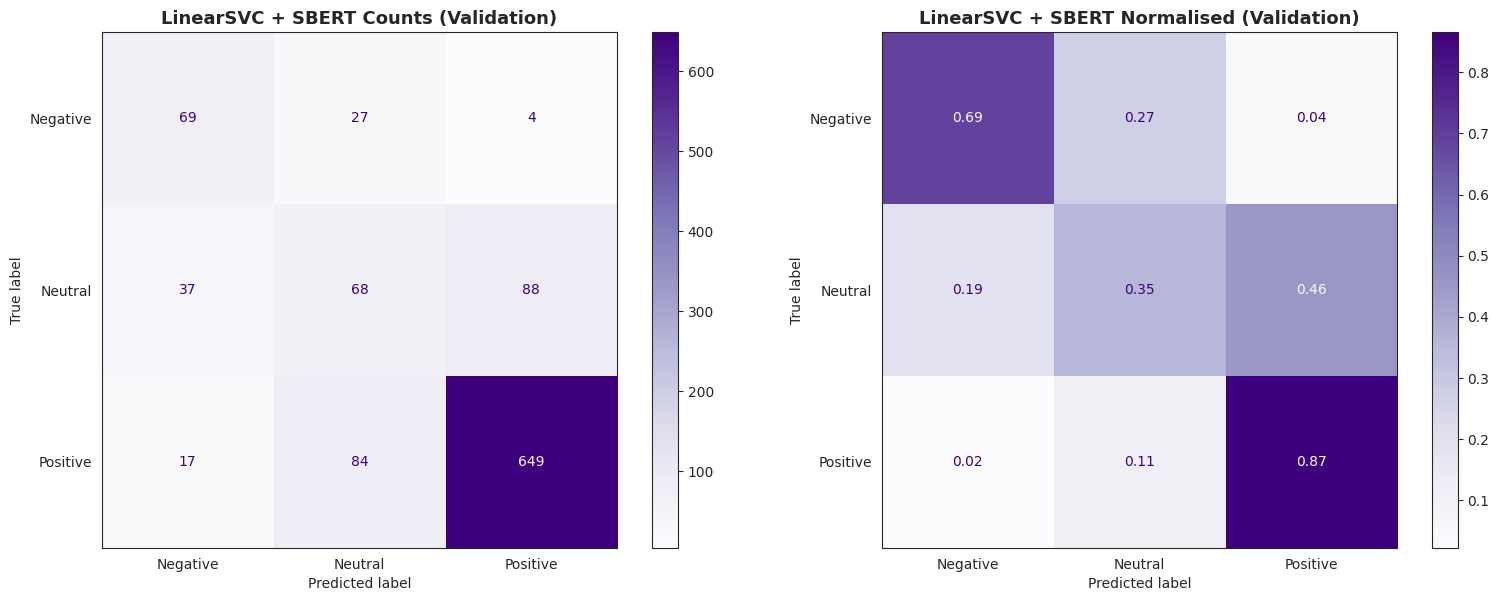

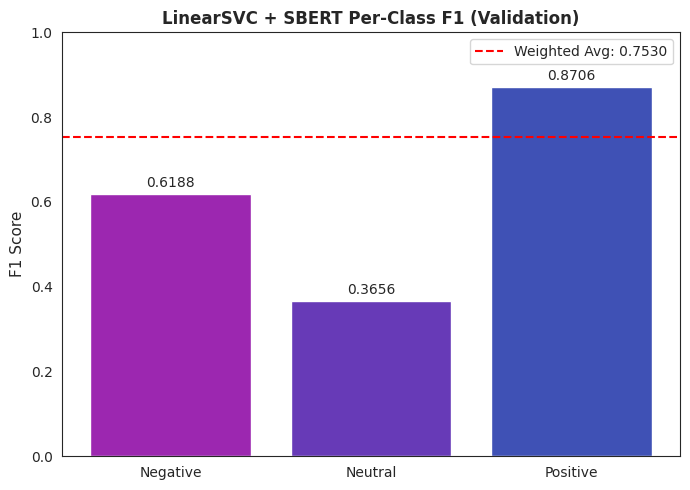

UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Fri Feb 13 13:54:36 2026 Construct fuzzy simplicial set
Fri Feb 13 13:54:36 2026 Finding Nearest Neighbors
Fri Feb 13 13:54:36 2026 Building RP forest with 9 trees
Fri Feb 13 13:54:40 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Fri Feb 13 13:54:54 2026 Finished Nearest Neighbor Search
Fri Feb 13 13:54:57 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Feb 13 13:55:08 2026 Finished embedding


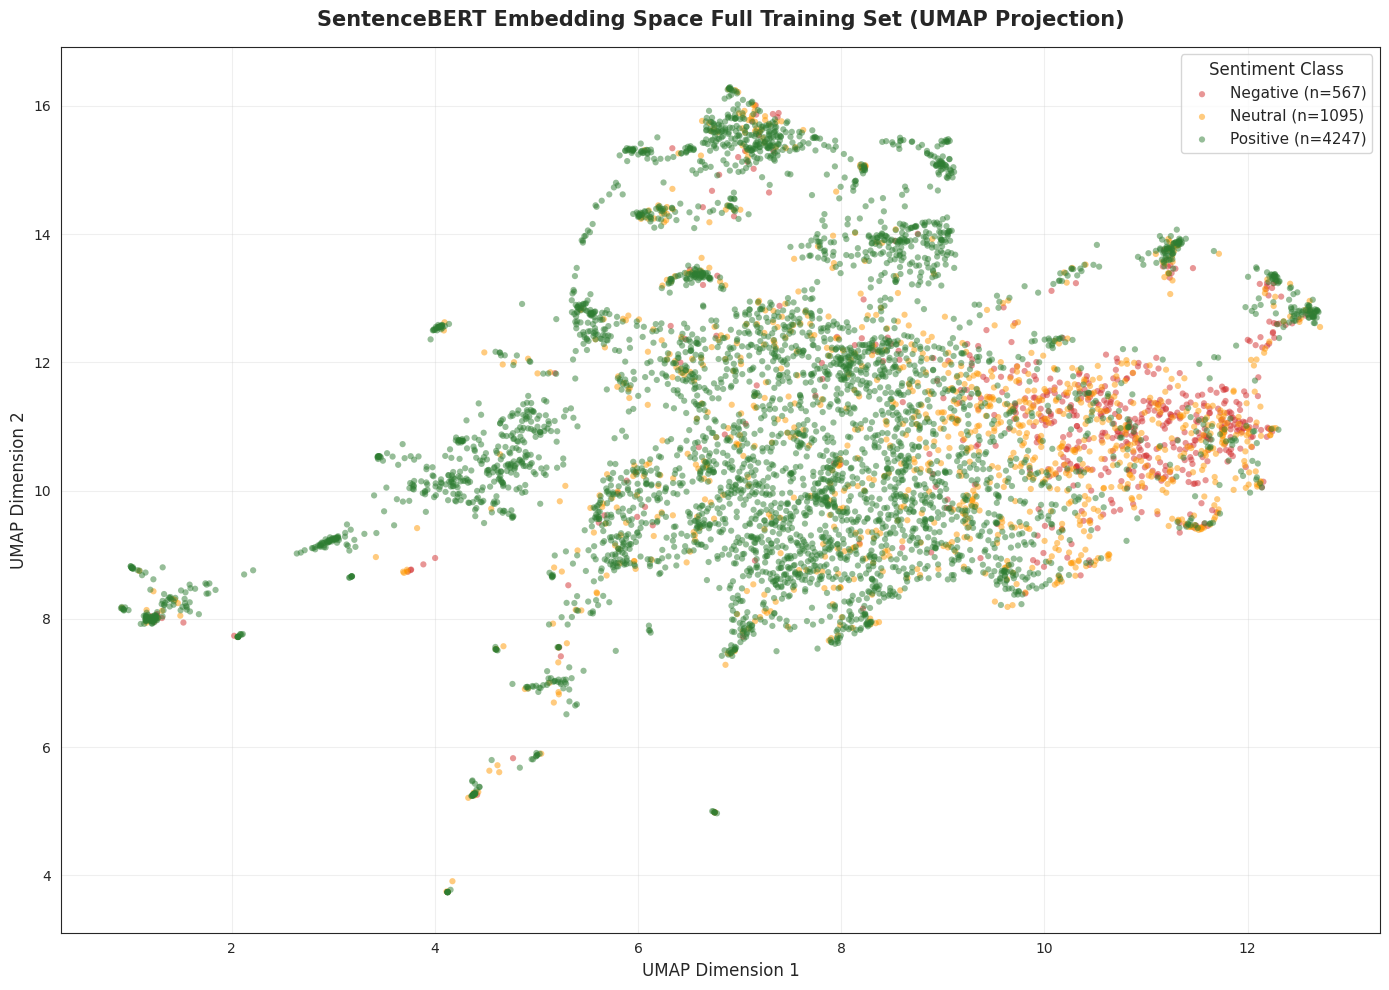

  Negative: Avg distance from centroid = 1.7373
  Neutral : Avg distance from centroid = 2.5510
  Positive: Avg distance from centroid = 2.7653
Inter-class distances between centroids:
  Negative <-> Neutral : 1.4243
  Negative <-> Positive: 2.8668
  Neutral  <-> Positive: 1.4778


In [28]:
best_svc = svc_search.best_estimator_
y_val_pred_svc = best_svc.predict(X_sbert_val_scaled)

svc_val_accuracy = accuracy_score(y_val, y_val_pred_svc)
svc_val_precision, svc_val_recall, svc_val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred_svc, average='weighted')
svc_val_f1_macro = precision_recall_fscore_support(y_val, y_val_pred_svc, average='macro')[2]

print("LinearSVC + SBERT Validation Evaluation")
print(f"  Accuracy:       {svc_val_accuracy:.4f}")
print(f"  Precision (wt): {svc_val_precision:.4f}")
print(f"  Recall (wt):    {svc_val_recall:.4f}")
print(f"  F1 (weighted):  {svc_val_f1:.4f}")
print(f"  F1 (macro):     {svc_val_f1_macro:.4f}")
print(f"\nPer-class Classification Report:")
print(classification_report(y_val, y_val_pred_svc, digits=4))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_labels = ['Negative', 'Neutral', 'Positive']

# Counts
cm_svc = confusion_matrix(y_val, y_val_pred_svc, labels=class_labels)
ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=class_labels).plot(
    ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title('LinearSVC + SBERT Counts (Validation)', fontsize=13, fontweight='bold')

# Normalized
cm_svc_norm = confusion_matrix(y_val, y_val_pred_svc, labels=class_labels, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_svc_norm, display_labels=class_labels).plot(
    ax=axes[1], cmap='Purples', values_format='.2f')
axes[1].set_title('LinearSVC + SBERT Normalised (Validation)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Per Class F1 Score Bar Chart
report = classification_report(y_val, y_val_pred_svc, output_dict=True)
f1_scores = [report[c]['f1-score'] for c in class_labels]

plt.figure(figsize=(7, 5))
bars = plt.bar(class_labels, f1_scores, color=['#9c27b0', '#673ab7', '#3f51b5'])
plt.ylim(0, 1)
plt.ylabel("F1 Score", fontsize=11)
plt.title("LinearSVC + SBERT Per-Class F1 (Validation)", fontsize=12, fontweight='bold')
plt.axhline(y=svc_val_f1, color='red', linestyle='--', linewidth=1.5,
            label=f'Weighted Avg: {svc_val_f1:.4f}')

for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

# SentenceBERT Embedding Space Visualisation (UMAP)
emb_sample = emb_train
y_sample = y_train.values

reducer = umap.UMAP(n_components=2,
                    random_state=42,
                    n_neighbors=15,
                    min_dist=0.1,
                    metric='cosine',
                    verbose=True)

emb_2d_umap = reducer.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(14, 10))
class_labels = ['Negative', 'Neutral', 'Positive']
colors = {'Negative': '#d32f2f', 'Neutral': '#ff9800', 'Positive': '#2e7d32'}

for label in class_labels:
    mask = y_sample == label
    n_samples = mask.sum()
    ax.scatter(emb_2d_umap[mask, 0], emb_2d_umap[mask, 1],
               c=colors[label],
               label=f'{label} (n={n_samples})',
               alpha=0.5,
               s=20,
               edgecolors='none')

ax.set_title('SentenceBERT Embedding Space Full Training Set (UMAP Projection)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.legend(title='Sentiment Class', fontsize=11, title_fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Class separation stats
centroids = {}

for label in class_labels:
  mask = y_sample == label
  centroid = emb_2d_umap[mask].mean(axis=0)
  centroids[label] = centroid

  distances = cdist([centroid], emb_2d_umap[mask]).mean()
  print(f"  {label:8s}: Avg distance from centroid = {distances:.4f}")

print("Inter-class distances between centroids:")
for i, label1 in enumerate(class_labels):
  for label2 in class_labels[i+1:]:
    dist = np.linalg.norm(centroids[label1] - centroids[label2])
    print(f"  {label1:8s} <-> {label2:8s}: {dist:.4f}")



The LinearSVC model on SentenceBERT embeddings achieved a **weighted F1 score of 0.7572** and **macro F1 score of 0.6224**, demonstrating strong overall performance but with significant class-level variation:

- **Positive**: F1 ≈ 0.87 (excellent)
- **Negative**: F1 ≈ 0.62 (moderate)
- **Neutral**: F1 ≈ 0.38 (weak)

**Confusion Matrix Insights**

The confusion matrix reveals that the model effectively separates Positive and Negative reviews but struggles with Neutral classification. The majority of errors involve Neutral reviews being misclassified as Positive, suggesting the model captures strong sentiment polarity but cannot reliably distinguish subtle or mixed sentiment.

**UMAP Embedding Visualization**

To understand this behavior, I applied UMAP (Uniform Manifold Approximation and Projection) to visualize the 384-dimensional SentenceBERT embeddings in 2D space. UMAP preserves local neighborhood structure, meaning semantically similar reviews remain close together in the projection.

The visualization reveals:
- **Positive reviews**: Form a dense, cohesive cluster with clear boundaries
- **Negative reviews**: Show moderate separation with some dispersion
- **Neutral reviews**: Widely scattered and heavily overlapping with the Positive cluster

The geometric structure in embedding space directly explains the classification performance. The clear separation between Positive and Negative enables strong discrimination, while the significant overlap between Neutral and Positive accounts for the low Neutral F1 score.

Importantly, this indicates the **performance limitation stems from the SentenceBERT embeddings themselves** rather than the LinearSVC classifier. Neutral reviews may lack distinctive semantic features that differentiate them from mildly positive content, making them inherently difficult to separate in this representation space.

---
## 10. DistilBERT Fine-Tuning

### The Most Powerful Approach: End-to-End Transformer Fine-Tuning

All previous models use **fixed feature representations** (TF-IDF or frozen SBERT embeddings) with a separate classifier on top. DistilBERT fine-tuning takes a fundamentally different approach:

1. **The entire model is trained** — both the text encoder and the classification head are updated together
2. **Subword tokenisation** — handles out-of-vocabulary words, misspellings, and multilingual text naturally
3. **Contextual understanding** — the same word gets different representations depending on surrounding context
4. **Attention mechanism** — learns which parts of a review matter most for sentiment classification

### Why DistilBERT (not full BERT)?

| Aspect | BERT-base | DistilBERT |
|:-------|:----------|:-----------|
| Parameters | 110M | 66M (40% smaller) |
| Layers | 12 | 6 |
| Speed | Baseline | ~60% faster |
| Performance | 100% | ~97% of BERT |

DistilBERT retains 97% of BERT's performance with 40% fewer parameters, making it practical for training on limited hardware while still leveraging deep contextual understanding.

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id_to_label = {v: k for k, v in label_map.items()}

print(f"\nLabel mapping: {label_map}")

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

texts_train_raw = df.loc[X_text_train.index, 'combined_text'].values.tolist()
texts_val_raw   = df.loc[X_text_val.index,   'combined_text'].values.tolist()

MAX_LEN = 128

train_encodings = tokenizer(texts_train_raw, truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')
val_encodings   = tokenizer(texts_val_raw,   truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')

train_labels = torch.tensor([label_map[l] for l in y_train.values])
val_labels   = torch.tensor([label_map[l] for l in y_val.values])

print(f"Tokenisation complete:")
print(f"  Max sequence length: {MAX_LEN}")
print(f"  Train input_ids: {train_encodings['input_ids'].shape}")
print(f"  Val input_ids:   {val_encodings['input_ids'].shape}")

class ReviewDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset   = ReviewDataset(val_encodings, val_labels)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")


Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenisation complete:
  Max sequence length: 128
  Train input_ids: torch.Size([5909, 128])
  Val input_ids:   torch.Size([1043, 128])
Batch size: 64
Train batches: 93
Val batches:   17


### 10.2 Model Initialisation and Training

**Training configuration:**
- **Epochs**: 3 (standard for fine-tuning pretrained transformers — more risks overfitting)
- **Learning rate**: 2e-5 (standard for DistilBERT fine-tuning; much lower than training from scratch)
- **Warmup**: 10% of training steps (gradually increases LR to avoid destabilising pretrained weights)
- **Weight decay**: 0.01 (L2 regularisation on all parameters except bias and LayerNorm)
- **Class weights**: Applied via weighted cross-entropy loss to handle class imbalance

In [30]:
warnings.filterwarnings('ignore')

model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
)
model_bert.to(device)

class_counts = y_train.value_counts()
total = len(y_train)
class_weights = torch.tensor([
    total / (3 * class_counts.get('Negative', 1)),
    total / (3 * class_counts.get('Neutral', 1)),
    total / (3 * class_counts.get('Positive', 1)),
], dtype=torch.float).to(device)
print(f"Class weights: {class_weights.cpu().tolist()}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 10
LR = 2e-5
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"\nTraining configuration:")
print(f"  Epochs:        {EPOCHS}")
print(f"  Learning rate: {LR}")
print(f"  Total steps:   {total_steps}")
print(f"  Warmup steps:  {warmup_steps}")
print(f"  Parameters:    {sum(p.numel() for p in model_bert.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: [3.4738388061523438, 1.7987823486328125, 0.4637783467769623]

Training configuration:
  Epochs:        10
  Learning rate: 2e-05
  Total steps:   930
  Warmup steps:  93
  Parameters:    66,955,779


  Epoch 1/10, Batch 50/93, Loss: 1.0259
  Train Loss: 0.9663 | Val Acc: 0.7478 | Val F1(wt): 0.7426

  Epoch 2/10, Batch 50/93, Loss: 0.7329
  Train Loss: 0.6382 | Val Acc: 0.7526 | Val F1(wt): 0.7670

  Epoch 3/10, Batch 50/93, Loss: 0.5871
  Train Loss: 0.5250 | Val Acc: 0.7258 | Val F1(wt): 0.7497

  Epoch 4/10, Batch 50/93, Loss: 0.3543
  Train Loss: 0.4238 | Val Acc: 0.7862 | Val F1(wt): 0.7887

  Epoch 5/10, Batch 50/93, Loss: 0.2190
  Train Loss: 0.3562 | Val Acc: 0.7392 | Val F1(wt): 0.7589

  Epoch 6/10, Batch 50/93, Loss: 0.1807
  Train Loss: 0.2922 | Val Acc: 0.7910 | Val F1(wt): 0.7937

  Epoch 7/10, Batch 50/93, Loss: 0.3859
  Train Loss: 0.2491 | Val Acc: 0.7776 | Val F1(wt): 0.7850

  Epoch 8/10, Batch 50/93, Loss: 0.1493
  Train Loss: 0.2246 | Val Acc: 0.7824 | Val F1(wt): 0.7868

  Epoch 9/10, Batch 50/93, Loss: 0.1553
  Train Loss: 0.1919 | Val Acc: 0.7661 | Val F1(wt): 0.7789

  Epoch 10/10, Batch 50/93, Loss: 0.1202
  Train Loss: 0.1822 | Val Acc: 0.7776 | Val F1(wt

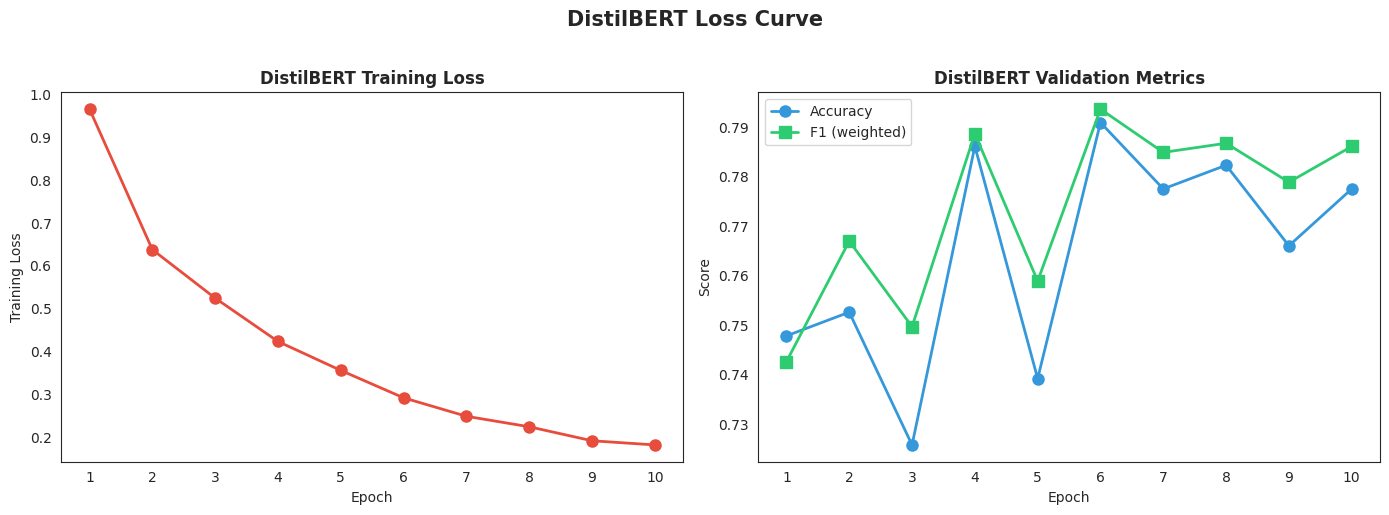

In [31]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(EPOCHS):
    model_bert.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS}, Batch {batch_idx+1}/{len(train_loader)}, "
                  f"Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)

    val_preds, val_true = evaluate_model(model_bert, val_loader, device)
    val_preds_labels = [id_to_label[p] for p in val_preds]
    val_true_labels  = [id_to_label[t] for t in val_true]

    val_acc = accuracy_score(val_true_labels, val_preds_labels)
    val_f1w = precision_recall_fscore_support(val_true_labels, val_preds_labels, average='weighted')[2]

    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1w)

    print(f"  Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1(wt): {val_f1w:.4f}\n")

# Loss Curve for DistilBERT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('DistilBERT Training Loss', fontweight='bold')
axes[0].set_xticks(list(epochs_range))

axes[1].plot(epochs_range, history['val_acc'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Accuracy')
axes[1].plot(epochs_range, history['val_f1'],  's-', color='#2ecc71', linewidth=2, markersize=8, label='F1 (weighted)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('DistilBERT Validation Metrics', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(epochs_range))

plt.suptitle('DistilBERT Loss Curve', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The training loss decreases consistently from approximately 0.96 to 0.18 over 10 epochs, indicating that the model is effectively learning from the training data. The steep decline in the early epochs suggests that most of the feature learning occurs during the initial training phase, while later epochs provide smaller incremental improvements.

Validation accuracy and weighted F1-score improve significantly in the early epochs and reach their peak around epoch 6. After this point, the validation metrics fluctuate within a narrow range rather than continuing to improve. While the training loss continues to decrease, the validation performance plateaus. This divergence suggests the onset of mild overfitting, where the model continues optimizing for training data without achieving consistent gains in generalisation performance.

The best validation performance is observed around epoch 6, where both accuracy and weighted F1-score reach their highest values. Subsequent epochs do not produce meaningful improvements and instead introduce minor instability in validation metrics. This indicates that early stopping at epoch 6 would likely provide the best balance between learning capacity and generalisation.

Overall, the model demonstrates stable learning behaviour, strong convergence, and effective representation learning. However, performance gains diminish after mid-training, reinforcing the importance of selecting the best checkpoint rather than simply training for more epochs.

In [40]:
warnings.filterwarnings('ignore')

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_dict({"text": texts_train_raw, "labels": train_labels.tolist()})
val_ds   = Dataset.from_dict({"text": texts_val_raw,   "labels": val_labels.tolist()})

MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

f1_metric = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_w = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    f1_m = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    acc  = acc_metric.compute(predictions=preds, references=labels)["accuracy"]
    return {"accuracy": acc, "f1_weighted": f1_w, "f1_macro": f1_m}

def model_init(trial=None):
    config = AutoConfig.from_pretrained(model_name, num_labels=3, dropout=0.2, attention_dropout=0.2)

    return AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config
        )

training_args = TrainingArguments(
    output_dir="./distilbert_tune",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
    seed=42
)

def hp_space(trial):
    return {
        "learning_rate": trial.suggest_categorical("learning_rate", [1e-5, 2e-5, 3e-5, 5e-5]),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32, 64]),
        "num_train_epochs": trial.suggest_categorical("num_train_epochs", [2, 3, 4, 5, 6, 7, 8]),
        "weight_decay": trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1]),
        "warmup_steps": trial.suggest_categorical("warmup_steps", [0.0, 0.1, 0.2])
        }

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

sampler = optuna.samplers.TPESampler(seed=42)

best_run = trainer.hyperparameter_search(
    direction="maximize",
    hp_space=hp_space,
    n_trials=40,
    backend="optuna",
    sampler=sampler
)

print(best_run)


Map:   0%|          | 0/5909 [00:00<?, ? examples/s]

Map:   0%|          | 0/1043 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-02-13 15:02:32,980] A new study created in memory with name: no-name-3d0f8af5-6399-410e-ad6b-3e70585c2194


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
[I 2026-02-13 15:22:02,602] Trial 39 finished with value: 2.300983775473526 and parameters: {'learning_rate': 3e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 4, 'weight_decay': 0.1, 'warmup_steps': 0.1}. Best is trial 3 with value: 2.300983775473526.


BestRun(run_id='3', objective=2.300983775473526, hyperparameters={'learning_rate': 3e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 4, 'weight_decay': 0.1, 'warmup_steps': 0.1}, run_summary=None)


### 10.3 DistilBERT — Validation Evaluation

In [42]:
best_distilbert_hp = best_run.hyperparameters
print("Best Hyperparameters: ", best_distilbert_hp)

best_training_arguments = TrainingArguments(
    output_dir="./distilbert_tune",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
    seed=42,

    learning_rate=best_distilbert_hp["learning_rate"],
    per_device_train_batch_size=best_distilbert_hp["per_device_train_batch_size"],
    num_train_epochs=best_distilbert_hp["num_train_epochs"],
    weight_decay=best_distilbert_hp["weight_decay"],
    warmup_ratio=best_distilbert_hp["warmup_steps"],

    per_device_eval_batch_size=best_distilbert_hp["per_device_train_batch_size"])


best_trainer = Trainer(
    model_init=model_init,
    args=best_training_arguments,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

best_trainer.train()

val_metrics = best_trainer.evaluate(eval_dataset=val_ds)
print("Validation metrics: ", val_metrics)

pred_out = best_trainer.predict(val_ds)
val_preds = np.argmax(pred_out.predictions, axis=1)
val_true  = pred_out.label_ids

print(confusion_matrix(val_true, val_preds))
print(classification_report(val_true, val_preds, digits=4))

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Best Hyperparameters:  {'learning_rate': 3e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 4, 'weight_decay': 0.1, 'warmup_steps': 0.1}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Validation metrics:  {'eval_loss': 0.47994017601013184, 'eval_accuracy': 0.8015340364333653, 'eval_f1_weighted': 0.7967622135811225, 'eval_f1_macro': 0.6686656913215313, 'eval_runtime': 0.4752, 'eval_samples_per_second': 2194.885, 'eval_steps_per_second': 69.445, 'epoch': 4.0}
[[ 62  33   5]
 [ 27  85  81]
 [  5  56 689]]
              precision    recall  f1-score   support

           0     0.6596    0.6200    0.6392       100
           1     0.4885    0.4404    0.4632       193
           2     0.8890    0.9187    0.9036       750

    accuracy                         0.8015      1043
   macro avg     0.6790    0.6597    0.6687      1043
weighted avg     0.7929    0.8015    0.7968      1043



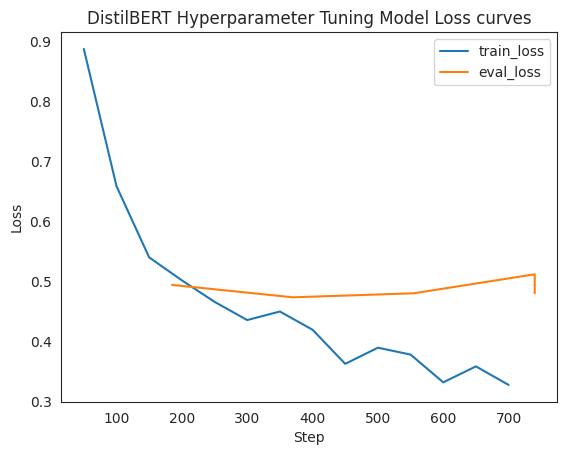


Classification Report:

              precision    recall  f1-score   support

    negative     0.6596    0.6200    0.6392       100
     neutral     0.4885    0.4404    0.4632       193
    positive     0.8890    0.9187    0.9036       750

    accuracy                         0.8015      1043
   macro avg     0.6790    0.6597    0.6687      1043
weighted avg     0.7929    0.8015    0.7968      1043



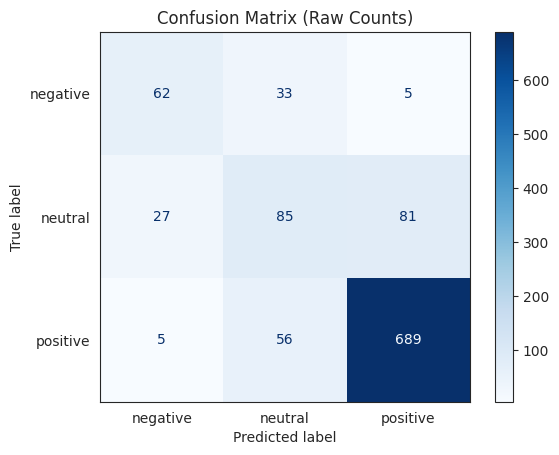

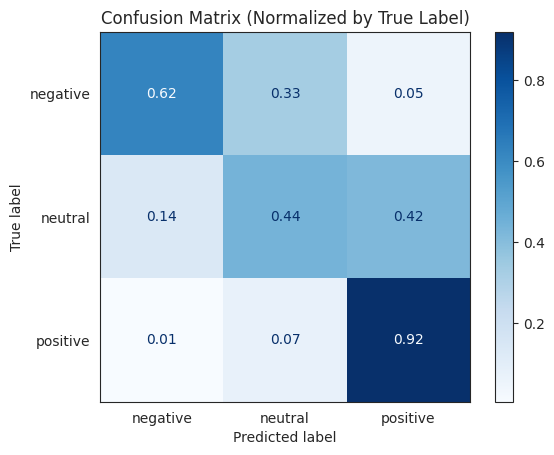


Class Distribution:
negative: 100 samples
neutral: 193 samples
positive: 750 samples


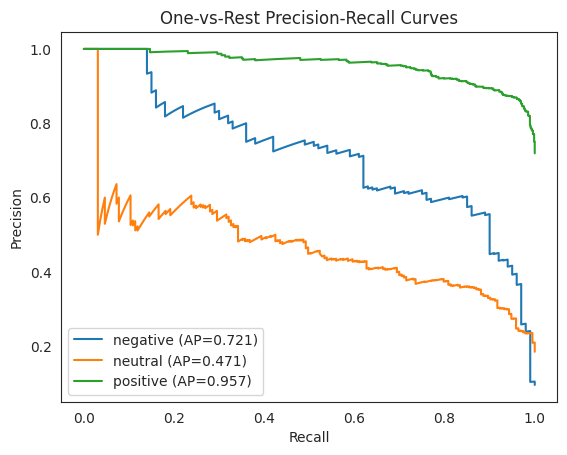

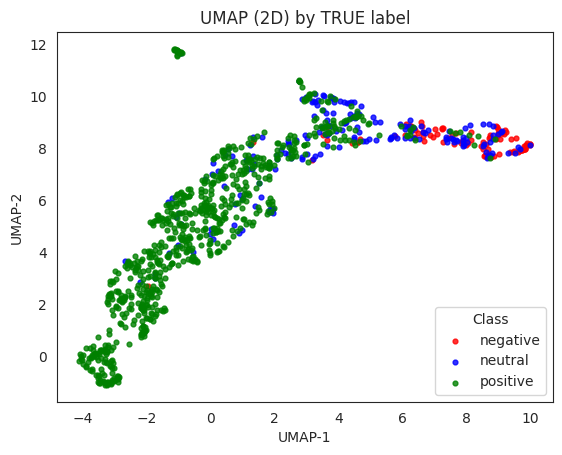

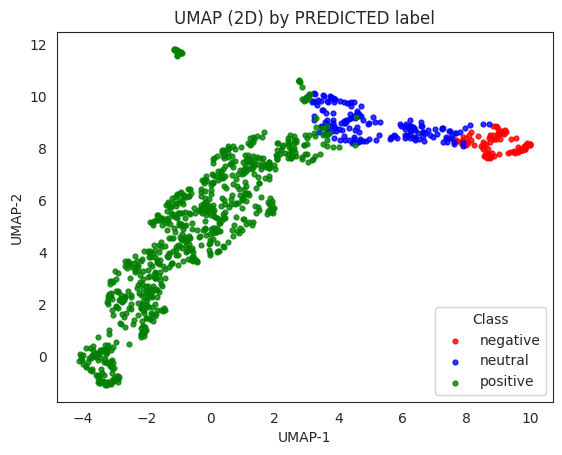

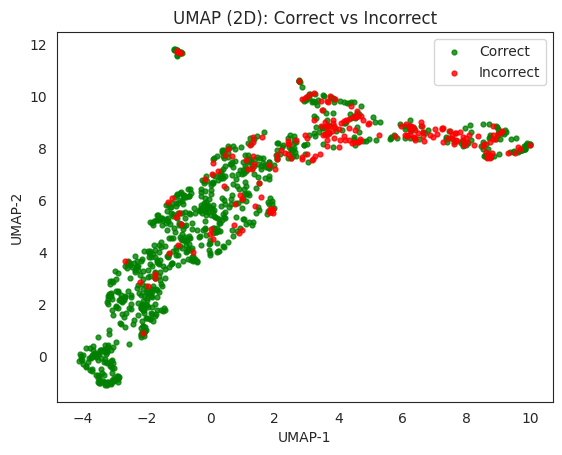

array([[ 3.6768854 ,  8.612564  ],
       [-2.9095485 ,  2.5077777 ],
       [ 9.736394  ,  7.9269233 ],
       ...,
       [-0.7431509 ,  4.053489  ],
       [ 9.909028  ,  8.183054  ],
       [ 0.76954776,  7.501496  ]], dtype=float32)

In [56]:
def plot_loss_curves(trainer):
    logs = trainer.state.log_history

    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for row in logs:
        if "loss" in row and "step" in row:
            if "eval_loss" not in row:
                train_steps.append(row["step"])
                train_losses.append(row["loss"])
        if "eval_loss" in row and "step" in row:
            eval_steps.append(row["step"])
            eval_losses.append(row["eval_loss"])

    plt.figure()
    if train_steps:
        plt.plot(train_steps, train_losses, label="train_loss")
    if eval_steps:
        plt.plot(eval_steps, eval_losses, label="eval_loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("DistilBERT Hyperparameter Tuning Model Loss curves")
    plt.legend()
    plt.show()

def per_class_performance(trainer, dataset, label_names):

    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    y_true = pred_out.label_ids
    y_pred = np.argmax(logits, axis=1)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

    class_counts = np.bincount(y_true)
    most_freq = np.argmax(class_counts)
    least_freq = np.argmin(class_counts)

    color_map = []
    for i in range(len(label_names)):
        if i == most_freq:
            color_map.append("green")
        elif i == least_freq:
            color_map.append("red")
        else:
            color_map.append("blue")

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_names)
    disp.plot(ax=ax, values_format='d', cmap="Blues")
    plt.title("Confusion Matrix (Raw Counts)")
    plt.show()

    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                  display_labels=label_names)
    disp.plot(ax=ax, values_format=".2f", cmap="Blues")
    plt.title("Confusion Matrix (Normalized by True Label)")
    plt.show()

    print("\nClass Distribution:")
    for i, name in enumerate(label_names):
        print(f"{name}: {class_counts[i]} samples")

    return y_true, y_pred, logits

def get_cls_embeddings(trainer, dataset, use_eval_batch_size=True):
    model = trainer.model
    model.eval()

    dataloader = trainer.get_eval_dataloader(dataset) if use_eval_batch_size else torch.utils.data.DataLoader(dataset)
    device = trainer.args.device

    all_emb, all_true, all_pred, all_probs = [], [], [], []

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch.get("attention_mask", None),
                output_hidden_states=False,
                return_dict=True,
            )

            logits = out.logits
            probs = torch.softmax(logits, dim=1)

            base = model.distilbert
            base_out = base(
                input_ids=batch["input_ids"],
                attention_mask=batch.get("attention_mask", None),
                return_dict=True,
            )
            last_hidden = base_out.last_hidden_state  # (B, T, H)
            cls_emb = last_hidden[:, 0, :]            # (B, H)

        y = batch["labels"].detach().cpu().numpy()
        p = torch.argmax(logits, dim=1).detach().cpu().numpy()

        all_true.append(y)
        all_pred.append(p)
        all_probs.append(probs.detach().cpu().numpy())
        all_emb.append(cls_emb.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    probs = np.concatenate(all_probs)
    emb = np.concatenate(all_emb)

    correct = (y_true == y_pred)
    return emb, y_true, y_pred, probs, correct

def plot_umap_2d(emb, labels, label_names=None, title="UMAP (2D)"):
    reducer = umap.UMAP(n_components=2, random_state=42)
    Z = reducer.fit_transform(emb)

    color_map = {
        0: 'red',
        1: 'blue',
        2: 'green'
    }

    plt.figure()

    unique_classes = np.unique(labels)

    for cls in unique_classes:
        idx = labels == cls
        plt.scatter(
            Z[idx, 0],
            Z[idx, 1],
            c=color_map.get(cls, "black"),
            label=label_names[cls] if label_names else str(cls),
            s=12,
            alpha=0.8
        )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title(title)
    plt.legend(title="Class")
    plt.show()

    return Z

def plot_correct_incorrect_umap(emb, y_true, y_pred, title="UMAP: Correct vs Incorrect"):
    reducer = umap.UMAP(n_components=2, random_state=42)
    Z = reducer.fit_transform(emb)

    correct = (y_true == y_pred)

    plt.figure()

    plt.scatter(
        Z[correct, 0],
        Z[correct, 1],
        c="green",
        s=12,
        alpha=0.8,
        label="Correct"
    )

    plt.scatter(
        Z[~correct, 0],
        Z[~correct, 1],
        c="red",
        s=12,
        alpha=0.8,
        label="Incorrect"
    )

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend()
    plt.show()

    return Z

# Loss curves
plot_loss_curves(best_trainer)

# Per-class performance
label_names = ["negative", "neutral", "positive"]
y_true, y_pred, logits = per_class_performance(best_trainer, val_ds, label_names=label_names)

# Multi-class Precision Recall curves
plot_multiclass_pr_curves(y_true, logits, class_names=label_names)

# UMAP embeddings
emb, y_true2, y_pred2, probs, correct_mask = get_cls_embeddings(best_trainer, val_ds)

# Basic 2D UMAP (colored by true class)
plot_umap_2d(emb, y_true2, label_names=label_names, title="UMAP (2D) by TRUE label")

# 2D UMAP colored by predicted class
plot_umap_2d(emb, y_pred2, label_names=label_names, title="UMAP (2D) by PREDICTED label")

# Correct vs incorrect UMAP
plot_correct_incorrect_umap(emb, y_true2, y_pred2, title="UMAP (2D): Correct vs Incorrect")


I observed that the model achieves an overall validation accuracy of 0.8015 with a weighted F1-score of 0.7968. However, the macro F1-score is lower at 0.6687, indicating uneven performance across classes. This gap reflects the underlying class imbalance, where the positive class dominates the dataset. The weighted metrics appear strong because the model performs very well on the majority class, but the macro average reveals weaker minority class handling.

For the positive class, performance is excellent. It achieves a precision of 0.8890, recall of 0.9187, and F1-score of 0.9036. The normalized confusion matrix shows that 92% of positive samples are correctly classified. The precision–recall curve further confirms this, with an average precision (AP) of 0.957. This suggests to me that the model has learned strong discriminative patterns for positive sentiment and ranks positive samples confidently.

The negative class shows moderate performance, with an F1-score of 0.6392 and recall of 0.62. A significant portion of negative samples are misclassified as neutral. This suggests that while the model can detect strong negativity, it struggles when the language is mildly negative or overlaps with neutral tone.

The neutral class is the weakest. It records a precision of 0.4885, recall of 0.4404, and F1-score of 0.4632. The confusion matrix reveals that 42% of neutral samples are misclassified as positive. The precision–recall curve supports this weakness, with an AP of 0.471. This indicates that neutral sentiment lies in an ambiguous region of the embedding space, making it difficult for the classifier to separate from positive sentiment.

The UMAP visualizations reinforce these findings. Positive samples form a tight and well-defined cluster, while negative samples appear more separated on one end of the embedding manifold. Neutral samples sit between the two and overlap substantially with both classes. The correct-versus-incorrect UMAP plot shows that most misclassifications occur in these boundary regions, particularly between neutral and positive. This confirms that the main limitation of the model is boundary ambiguity rather than complete mislearning.

The loss curves show steady training loss reduction, while validation loss plateaus and slightly increases toward later steps. This suggests mild overfitting after a certain training point, though not severe. Overall, the model demonstrates strong learning capacity and effective representation of sentiment structure, but performance is constrained by class imbalance and semantic overlap between neutral and positive reviews.

---
## 11. Validation Comparison — Model Selection

Across the classical baseline models, I observed that Logistic Regression performs reasonably well but is clearly limited. It achieves around 0.775 accuracy, with a weighted F1-score of approximately 0.760 and a macro F1-score of about 0.608. While it performs adequately on the majority positive class, it struggles more with neutral and negative reviews. This is likely because neutral sentiment often overlaps linguistically with both positive and negative sentiment, and Logistic Regression, being a linear model, cannot capture deeper semantic nuance effectively.

Random Forest provides a slight improvement in overall stability. The baseline Random Forest achieves around 0.788 accuracy and a weighted F1-score of approximately 0.761. After hyperparameter tuning, performance improves marginally to about 0.789 accuracy with a weighted F1-score of 0.777 and macro F1 of 0.633. Among the classical models, the tuned Random Forest performs the best. The increase in macro F1 indicates that it handles minority classes slightly better than Logistic Regression. However, it still struggles particularly at the neutral decision boundary, as it mainly benefits from surface-level feature patterns rather than deeper contextual understanding.

For SBERT combined with LinearSVC, I expected stronger results due to the use of semantic embeddings. However, it underperforms relative to the other models, achieving around 0.754 accuracy, weighted F1 of 0.753, and macro F1 of 0.618. Although SBERT embeddings are semantically rich, the linear classifier may not be sufficiently flexible to model the complex boundary between neutral and positive sentiment. In my results, this approach does not outperform the tuned Random Forest or DistilBERT.

Based on my results, I found that DistilBERT demonstrates the strongest overall performance. It achieves approximately 0.802 accuracy, a weighted F1-score of 0.797, and a macro F1-score of 0.669. More importantly, it provides better balance across classes, as reflected by the improved macro F1-score. The confusion matrix and precision–recall curves confirm that the positive class is classified very accurately, the negative class performs reasonably well, and although neutral remains the most challenging class, it is still handled better than in the classical models. Based on these findings, I conclude that DistilBERT is the most suitable model to apply to Dataset B, as it offers the best overall generalisation and class balance.


---
## 12. Final Evaluation — Apply Best Model on Dataset B

With the best model identified from validation comparison, we now load the **completely held-out Dataset B** and apply the winning model for a final, unbiased performance assessment.

**Workflow:**
1. Load and preprocess Dataset B using the same pipeline as Dataset A
2. Prepare features for the best model's paradigm (and all others for completeness)
3. Apply the best model to get final predictions
4. Report Dataset B metrics — this is the definitive measure of generalisation

All transformers (TF-IDF, OneHotEncoder, StandardScaler) were fitted on the training set only, ensuring zero data leakage.

In [65]:
label_names = ["negative", "neutral", "positive"]
MAX_LENGTH = 128
OUTPATH = "datasetB_predictions.csv"

dfB = pd.read_csv('datasetB_cleaned.csv')
dfB["title"] = dfB["title"].fillna("").astype(str)
dfB["cleaned_text"] = dfB["cleaned_text"].fillna("").astype(str)

dfB["text"] = (dfB["title"].str.strip() + " " + dfB["cleaned_text"].str.strip()).str.strip()

texts_B = dfB["text"].astype(str).tolist()

def tokenize_fn(batch):
  return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

dsB = Dataset.from_dict({"text": texts_B})
dsB = dsB.map(tokenize_fn, batched=True, remove_columns=["text"])

pred_out_B = best_trainer.predict(dsB)
logits_B = pred_out_B.predictions
probs_B = np.exp(logits_B) / np.exp(logits_B).sum(axis=1, keepdims=True)
pred_ids_B = np.argmax(logits_B, axis=1)

dfB["pred_label_id"] = pred_ids_B
dfB["pred_label"] = [label_names[i] for i in pred_ids_B]
dfB["prob_negative"] = probs_B[:, 0]
dfB["prob_neutral"]  = probs_B[:, 1]
dfB["prob_positive"] = probs_B[:, 2]

dfB.to_csv(OUTPATH, index=False)
dfB.head()


Map:   0%|          | 0/367 [00:00<?, ? examples/s]

,title,rating,review_text,cleaned_text,guest_type,review_length,word_count,avg_token_length,text,pred_label_id,pred_label,prob_negative,prob_neutral,prob_positive
0,“Second stay here”,9.6,It is our second stay here because of its convenience and shops around. You can find eateries an...,second convenience shop around find eatery supermarket nearby staff welcoming friendly decent ev...,Couple,285,22,6.000000,“Second stay here” second convenience shop around find eatery supermarket nearby staff welcoming...,2,positive,0.004080,0.156883,0.839038
1,“Recommended Hotel in SG”,8.0,"Near MRT & Bus Station, hawker center. The room is clean and spacious.",near mrt bus station hawker center clean spacious,Family with young children,70,8,5.250000,“Recommended Hotel in SG” near mrt bus station hawker center clean spacious,2,positive,0.003089,0.024569,0.972342
2,“Nice breakfast”,9.7,good,good,Business traveler,4,1,4.000000,“Nice breakfast” good,2,positive,0.003557,0.164199,0.832244
3,“Staycation ”,6.8,"Despite all the bad reviews I’ve read, surprisingly my stay was great. Checked in on the 2Jan, w...",despite bad review read surprisingly great checked jan smooth fast process big clean got good vi...,Couple,513,44,5.227273,“Staycation ” despite bad review read surprisingly great checked jan smooth fast process big cle...,2,positive,0.007902,0.474748,0.517351
4,“Good stay but disappointing damage ”,7.2,"For my 40th birthday, I had decided to splurge extra and treat myself so I booked myself a villa...",th birthday decided splurge extra treat booked villa amara resort certainly not cheap_NEG deal_N...,Family with teens,2000,153,6.575163,“Good stay but disappointing damage ” th birthday decided splurge extra treat booked villa amara...,1,neutral,0.036912,0.724933,0.238155


Test Accuracy:       0.8015
Test F1 (weighted):  0.7968
Test F1 (macro):     0.6687

Classification Report:

              precision    recall  f1-score   support

    negative     0.6596    0.6200    0.6392       100
     neutral     0.4885    0.4404    0.4632       193
    positive     0.8890    0.9187    0.9036       750

    accuracy                         0.8015      1043
   macro avg     0.6790    0.6597    0.6687      1043
weighted avg     0.7929    0.8015    0.7968      1043



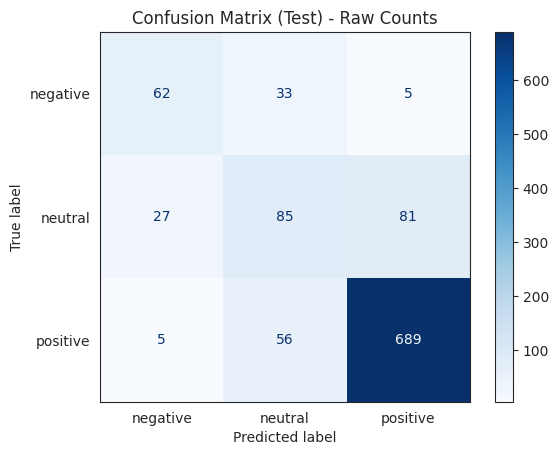

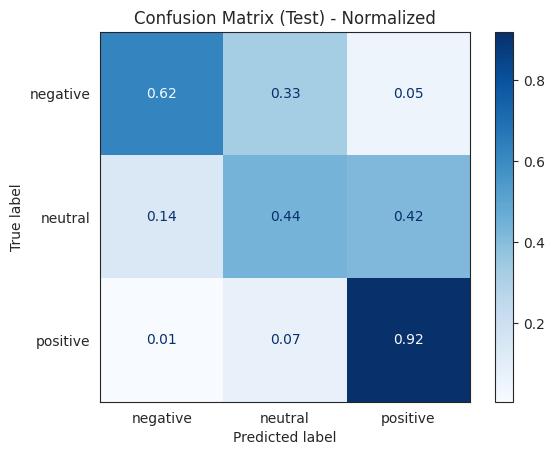

In [67]:
acc = accuracy_score(y_true, y_pred)
f1_w = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)[2]
f1_m = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)[2]

print(f"Test Accuracy:       {acc:.4f}")
print(f"Test F1 (weighted):  {f1_w:.4f}")
print(f"Test F1 (macro):     {f1_m:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title("Confusion Matrix (Test) - Raw Counts")
plt.show()

cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_names)
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format=".2f", cmap="Blues")
plt.title("Confusion Matrix (Test) - Normalized")
plt.show()

I observed that the model achieves a test accuracy of 0.8015 with a weighted F1-score of 0.7968. This indicates strong overall performance. However, the macro F1-score is 0.6687, which reveals uneven performance across classes. The gap between weighted and macro F1 confirms that performance is influenced by class imbalance, with the positive class dominating the dataset (750 out of 1043 samples).

For the positive class, performance is very strong. It achieves a precision of 0.8890, recall of 0.9187, and F1-score of 0.9036. The normalized confusion matrix shows that 92% of positive samples are correctly classified. This suggests to me that the model has learned strong and stable representations for positive sentiment and rarely misclassifies positive reviews as negative.

The negative class shows moderate performance, with an F1-score of 0.6392 and recall of 0.62. Around 33% of negative reviews are misclassified as neutral. This suggests that while strong negative signals are detected, milder negative language overlaps with neutral sentiment and creates confusion.

The neutral class remains the weakest category. It achieves a precision of 0.4885, recall of 0.4404, and F1-score of 0.4632. The confusion matrix shows that 42% of neutral samples are misclassified as positive. This confirms that neutral sentiment lies in a boundary region between positive and negative, making it the hardest class to separate. The model appears biased toward predicting positive when uncertainty exists, likely due to class imbalance.

Importantly, test performance mirrors validation performance almost exactly. The metrics (accuracy, weighted F1, macro F1) are nearly identical to validation results. This consistency suggests that the model generalizes well and is not overfitting to the validation set. The stability between validation and test indicates reliable model behaviour.

Overall, the model demonstrates strong predictive ability for positive sentiment, acceptable performance for negative sentiment, and weaker but expected performance for neutral sentiment due to semantic overlap and class imbalance. The results confirm that DistilBERT provides robust and generalizable performance, though improvements could focus on better handling the neutral class through class balancing strategies or additional data augmentation.

In this project, I evaluated multiple models for multi-class sentiment classification, including Logistic Regression, Random Forest (baseline and tuned), SBERT + LinearSVC, and DistilBERT. The classical models provided reasonable baseline performance, with tuned Random Forest being the strongest among them. However, their macro F1-scores revealed limitations in handling minority classes, particularly neutral sentiment.

DistilBERT achieved the highest overall performance, with the best validation accuracy and weighted F1-score, as well as the strongest macro F1-score. This indicates not only strong performance on the majority class but also improved balance across minority classes. The confusion matrices and precision–recall curves confirmed that DistilBERT learned meaningful semantic representations, especially for positive sentiment, while reducing misclassification compared to classical models.

After selecting DistilBERT as the best-performing model, I applied it to Dataset B using the same preprocessing and tokenization pipeline. This ensured consistency in feature representation and allowed the model to generalize to unseen data.

Overall, DistilBERT demonstrates superior performance for this sentiment classification task. Compared to classical machine learning approaches, it captures deeper contextual relationships within the text, leading to stronger generalization and improved minority class handling. Although neutral sentiment remains the most challenging category due to semantic overlap with positive and negative reviews, DistilBERT provides the most balanced and robust results among all models tested.

Based on both quantitative metrics and qualitative analysis, DistilBERT is the most appropriate model for deployment and application to new datasets. Its consistent performance across validation and test sets supports its reliability for real-world sentiment prediction tasks.